In [35]:
import numpy as np
import sklearn as skl
import matplotlib.pyplot as plt
import scipy.stats as sp
from sklearn.neighbors import KernelDensity
from tqdm import tqdm
import scipy.integrate as itg

In [7]:
spin_sample = np.random.uniform(0, 1, size=1000)
M_sample = np.random.normal(loc=1, scale=0.02, size=1000)

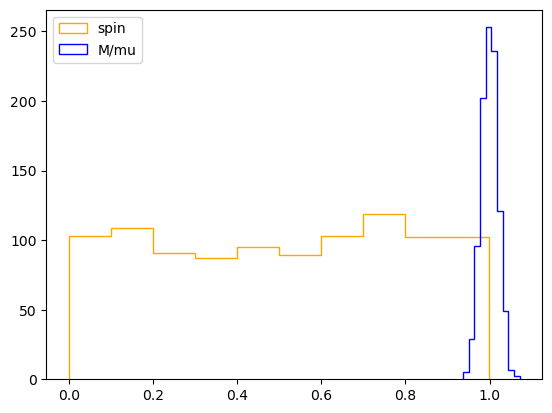

In [8]:
plt.hist(spin_sample, histtype='step', color='orange', label='spin')
plt.hist(M_sample, histtype='step', color='blue', label='M/mu')
plt.legend()

In [9]:
def calc_f(spin): return np.sqrt(0.5*(1+np.sqrt(1-spin**2)))

In [10]:
x = M_sample*calc_f(spin_sample)

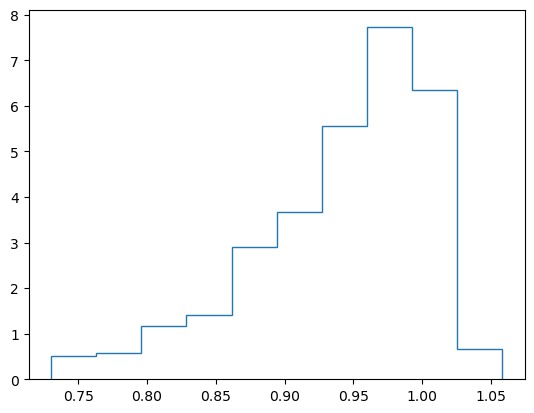

In [11]:
plt.hist(x, density=True, histtype='step')
plt.show()

In [12]:
def kde_sklearn(data, bandwidth=1.0, kernel="linear", xgrid=np.linspace(0, 1, 1000)):
    kde_skl = KernelDensity(bandwidth=bandwidth, kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

In [13]:
f_dist = calc_f(spin_sample)

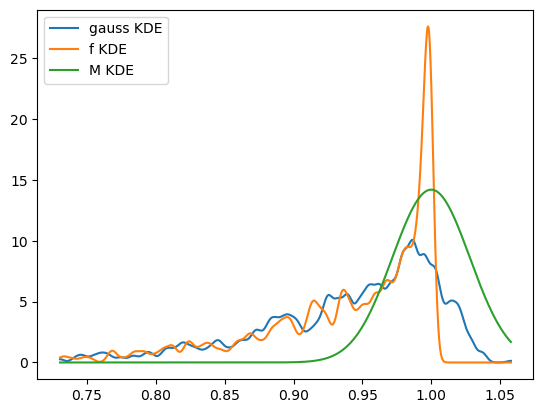

In [27]:
xgrid = np.linspace(x.min(), x.max(), 1000)
pdf_gauss = kde_sklearn(x, bandwidth=0.003, kernel='gaussian', xgrid=xgrid)
#pdf_tophat = kde_sklearn(x, bandwidth=0.01, kernel='tophat', xgrid=xgrid)
pdf_f = kde_sklearn(f_dist, bandwidth=0.003, kernel='gaussian', xgrid=xgrid)
pdf_M = kde_sklearn(M_sample, bandwidth=0.02, kernel='gaussian', xgrid=xgrid)
plt.plot(xgrid, pdf_gauss, label='gauss KDE')
#plt.plot(xgrid, pdf_tophat, label='tophat kernel')
plt.plot(xgrid, pdf_f, label='f KDE')
plt.plot(xgrid, pdf_M, label='M KDE')
plt.legend()
plt.show()

In [23]:
sigmas = np.linspace(0.0001, 0.15, 100)
pvalues = np.zeros((2,len(sigmas)))
for i in tqdm(range(len(sigmas))):
    pdf_gauss = kde_sklearn(x, bandwidth=sigmas[i], kernel='gaussian', xgrid=xgrid)
    pvalues[0,i] = np.array(sp.ks_2samp(pdf_gauss, pdf_f).pvalue)
    pvalues[1,i] = np.array(sp.ks_2samp(pdf_gauss, pdf_M).pvalue)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:03<00:00, 26.76it/s]


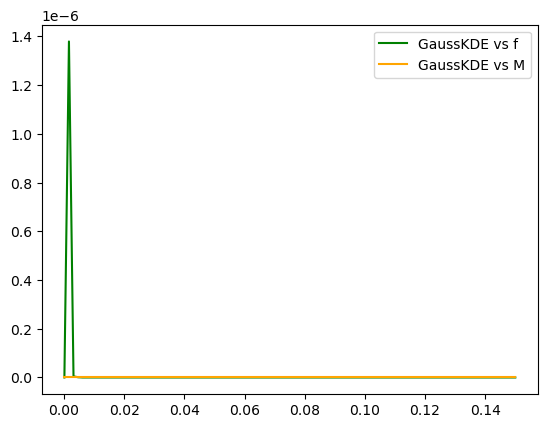

In [24]:
plt.plot(sigmas, pvalues[0], c='green', label='GaussKDE vs f')
plt.plot(sigmas, pvalues[1], c='orange', label='GaussKDE vs M')
#plt.yscale('log')
plt.legend()
plt.show()

In [41]:
def calc_f_pdf (f): return 2 * (2*f**2 - 1) / (np.sqrt(1 - f**2))
def Mirr_integrand (f, M, sigma): return np.exp(-M/(f-1)**2 / 2*sigma**2) * (2*f**2-1)/(f*np.sqrt(1-f**2))
def calc_Mirr_pdf (M, sigma): return np.sqrt(2/np.pi)/sigma * itg.quad(func=Mirr_integrand, a=1/np.sqrt(2), b=1, args=(M, sigma))[0]

In [54]:
Mirr_pdf = np.array([calc_Mirr_pdf(M=Mval, sigma=0.02) for Mval in x])

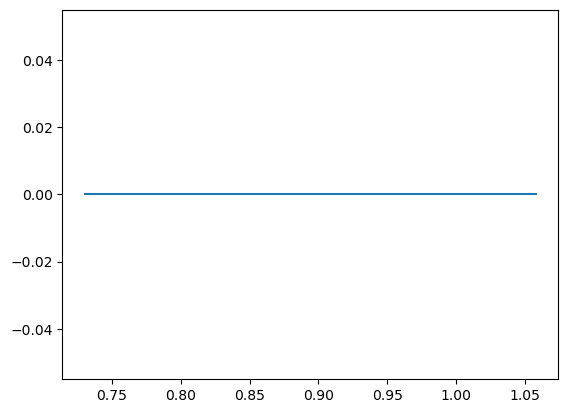

In [ ]:
pdf_Mirr = kde_sklearn(Mirr_pdf, bandwidth=0.02, kernel='gaussian', xgrid=xgrid)
plt.plot(xgrid, pdf_Mirr, label='Mirr KDE')